# Sangatta CoastCheck

## Purpose

Sandra et al. (2025) measured five Sangatta River segments, classified
the river as heavily polluted, and called for regular monitoring. Those
published STORET measurements describe river conditions but cannot map
how the signal extends along the coast.

This capstone brings the published measurements together with the
existing Tanager result. It shows the relative coastal signal, checks
that pattern against same-day Sentinel-2 processed with ACOLITE, ranks
six fixed 1 km monitoring zones, and shows how repeated Tanager scenes
could support monitoring.

**Result:** N1, immediately north of the river mouth, ranked first.
S1, immediately south, ranked second. They are the first places to
recheck, not confirmed pollution sources and not proof of mangrove
damage.


## Method and limits

### Published river measurements

Sandra et al. (2025) measured five Sangatta River segments, classified
the river as heavily polluted, and called for regular monitoring. The
river supports local communities and ecosystems, including drinking,
domestic and fisheries uses. Point samples are essential, but they do
not provide a continuous coastal map.

### Coastal signal and same-day check

Published Indonesian studies show that satellite imagery can map the
full spatial pattern of coastal turbidity and that estuary plume
position changes with rainfall, season and tides. Tanager supplies the
detailed spectrum needed to choose narrow red and near-infrared bands.
Same-day Sentinel-2 processed with ACOLITE provides an independent
processing path for checking the mapped pattern.

### Interpretation

The values are satellite estimates. They rank places for repeat
monitoring; they do not identify the pollution source or prove
ecological harm.


## Data

### Source files


In [1]:
from pathlib import Path
import warnings

import geopandas as gpd
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
from rasterio.transform import array_bounds
from rasterio.warp import reproject, Resampling
from scipy.ndimage import binary_erosion, distance_transform_edt
from scipy.stats import rankdata, spearmanr


def find_root(start=Path.cwd()):
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'data').exists() or (candidate / 'data' / 'published_storet_scores.csv').exists():
            return candidate
    return start.resolve()


ROOT = find_root()
OUT_DIR = Path.cwd().resolve() if (Path.cwd() / 'data').exists() else ROOT
DATA_DIR = OUT_DIR / 'data'
FIGURE_DIR = OUT_DIR / 'figures'
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SCENE_ID = '20250302_030003_92_4001'
TANAGER_DIR_CANDIDATES = [
    ROOT / 'data' / 'coastal' / SCENE_ID,
    ROOT / 'data' / 'coastal' / SCENE_ID,
    ROOT.parent / 'data' / 'coastal' / SCENE_ID,
]
TANAGER_DIR = next((p for p in TANAGER_DIR_CANDIDATES if p.exists()), TANAGER_DIR_CANDIDATES[0])

ACOLITE_DIR_CANDIDATES = [
    ROOT / 'data' / 'acolite' / 'sangatta_s2c_20250302',
    ROOT / 'data' / 'acolite' / 'sangatta_s2c_20250302',
    ROOT.parent / 'data' / 'acolite' / 'sangatta_s2c_20250302',
]
ACOLITE_DIR = next((p for p in ACOLITE_DIR_CANDIDATES if p.exists()), ACOLITE_DIR_CANDIDATES[0])

SR_PATH = TANAGER_DIR / 'ortho_sr_hdf5.h5'
VISUAL_PATH = TANAGER_DIR / 'ortho_visual.tif'
S2_TUR_PATH = next(ACOLITE_DIR.glob('*TUR_Dogliotti2015.tif'))

GMW_CANDIDATES = [
    DATA_DIR / 'gmw_clipped.geojson',
    ROOT / 'data' / 'gmw_clipped.geojson',
    ROOT / 'presentations' / 'coastal_tanager_evidence' / 'data' / 'gmw_clipped.geojson',
    ROOT.parent / 'presentations' / 'coastal_tanager_evidence' / 'data' / 'gmw_clipped.geojson',
]
GMW_PATH = next((p for p in GMW_CANDIDATES if p.exists()), None)

MOUTH_CANDIDATES = [
    DATA_DIR / 'mouth_seed.geojson',
    ROOT / 'data' / 'mouth_seed.geojson',
    ROOT / 'presentations' / 'coastal_tanager_evidence' / 'data' / 'mouth_seed.geojson',
    ROOT.parent / 'presentations' / 'coastal_tanager_evidence' / 'data' / 'mouth_seed.geojson',
]
MOUTH_PATH = next((p for p in MOUTH_CANDIDATES if p.exists()), None)

for name, path in [('SR', SR_PATH), ('Visual', VISUAL_PATH), ('S2_TUR', S2_TUR_PATH), ('GMW', GMW_PATH), ('Mouth', MOUTH_PATH)]:
    assert path is not None and path.exists(), f'Missing input: {name} -> {path}'

print('Working directory:', OUT_DIR)
print('Data folder:', DATA_DIR)
print('Figures folder:', FIGURE_DIR)


Output folder: Coastal_Analysis


### Display style


In [2]:
INK = "#17212B"
BLUE = "#1769AA"
BLUE_DARK = "#0B3C5D"
BLUE_LIGHT = "#A9D6E5"
ORANGE = "#E67E22"
ORANGE_LIGHT = "#F5B35C"
GOLD = "#E9B949"
GREEN = "#16856B"
GREY = "#697586"
LIGHT = "#E8EEF2"
VERY_LIGHT = "#F5F8FA"
SIGNAL_CMAP = LinearSegmentedColormap.from_list(
    "coastal_signal",
    ["#FFF8E8", "#F8D477", "#EE9B32", "#D45A16", "#7F2704"],
)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "text.color": INK,
    "axes.labelcolor": INK,
    "axes.edgecolor": "#CBD5E1",
    "axes.titlecolor": INK,
    "axes.titlesize": 20,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})


def save_figure(fig, filename, dpi=375):
    """Save lossless, slide-ready PNGs; selected maps use 7200 x 4050."""
    path = FIGURE_DIR / filename
    fig.savefig(
        path,
        dpi=dpi,
        facecolor=fig.get_facecolor(),
        edgecolor="none",
        bbox_inches=None,
        pad_inches=0,
    )
    print("Saved:", path)


def extent_for(transform, shape):
    west, south, east, north = array_bounds(shape[0], shape[1], transform)
    return [west, east, south, north]


def clean_axis(axis):
    axis.spines[["top", "right"]].set_visible(False)
    axis.grid(axis="x", color=LIGHT, linewidth=1)
    axis.set_axisbelow(True)


def true_colour_rgba(rgb):
    """Make no-data transparent and apply a restrained display stretch."""
    array = rgb.astype("float32")
    if np.nanmax(array) > 1:
        array = array / 255.0
    alpha = (np.nansum(array, axis=2) > 0).astype("float32")
    valid = alpha > 0
    for band in range(array.shape[2]):
        low, high = np.nanpercentile(array[..., band][valid], [2, 98])
        if high > low:
            array[..., band] = (array[..., band] - low) / (high - low)
    array = np.clip(array, 0, 1) ** 0.92
    return np.dstack([np.clip(array, 0, 1), alpha])


def add_map_furniture(axis, length_m=2000, color="white"):
    """Add only the orientation marks that must remain attached to a map."""
    x0, x1 = axis.get_xlim()
    y0, y1 = axis.get_ylim()
    axis.annotate(
        "N",
        xy=(x1 - 0.055 * (x1 - x0), y1 - 0.055 * (y1 - y0)),
        xytext=(x1 - 0.055 * (x1 - x0), y1 - 0.15 * (y1 - y0)),
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color=color,
        arrowprops=dict(arrowstyle="-|>", color=color, linewidth=2.0),
        zorder=20,
    )
    bar_x = x0 + 0.06 * (x1 - x0)
    bar_y = y0 + 0.065 * (y1 - y0)
    axis.plot(
        [bar_x, bar_x + length_m],
        [bar_y, bar_y],
        color=color,
        linewidth=3.5,
        solid_capstyle="butt",
        zorder=20,
    )
    axis.plot(
        [bar_x, bar_x, bar_x + length_m, bar_x + length_m],
        [bar_y - 70, bar_y + 70, bar_y - 70, bar_y + 70],
        color=color,
        linewidth=1.3,
        zorder=20,
    )
    axis.text(
        bar_x + length_m / 2,
        bar_y + 130,
        f"{length_m / 1000:g} km",
        ha="center",
        va="bottom",
        fontsize=12.5,
        fontweight="bold",
        color=color,
        zorder=20,
    )


### Tanager turbidity


In [3]:
DF = "HDFEOS/GRIDS/HYP/Data Fields"
FILL = -9999.0
A_RED, C_RED = 228.1, 0.1641
A_NIR, C_NIR = 3078.9, 0.2112

with rasterio.open(VISUAL_PATH) as source:
    target_transform = source.transform
    target_crs = source.crs
    target_shape = source.shape
    visual = np.moveaxis(source.read([1, 2, 3]), 0, -1)

with h5py.File(SR_PATH, "r") as h5:
    surface_reflectance = h5[f"{DF}/surface_reflectance"]
    wavelengths = np.asarray(surface_reflectance.attrs["wavelengths"], float)
    good = np.asarray(surface_reflectance.attrs["good_wavelengths"]).astype(bool)

    def band_window(low, high):
        return np.where((wavelengths >= low) & (wavelengths <= high) & good)[0]

    def band_mean(ids):
        values = surface_reflectance[ids].astype("float32")
        values[values == FILL] = np.nan
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            return np.nanmean(values, axis=0)

    red = band_mean(band_window(620, 670))
    nir = band_mean(band_window(841, 876))
    swir = band_mean(band_window(1600, 1620))
    green = band_mean(band_window(558, 562))
    nodata = h5[f"{DF}/nodata_pixels"][:]
    cloud = h5[f"{DF}/beta_cloud_mask"][:]
    cirrus = h5[f"{DF}/beta_cirrus_mask"][:]

ndwi = (green - nir) / (green + nir)
water = (
    (nodata == 0) & (cloud == 0) & (cirrus == 0)
    & np.isfinite(red) & (ndwi > 0)
)
red_corrected = np.clip(red - swir, 0, None)
nir_corrected = np.clip(nir - swir, 0, None)
nir_weight = np.clip((red_corrected - 0.05) / 0.02, 0, 1)

def turbidity(reflectance, a_value, c_value):
    bounded = np.clip(reflectance, 0, 0.9 * c_value)
    return a_value * bounded / (1 - bounded / c_value)

saturated = water & (
    (red_corrected > 0.9 * C_RED) | (nir_corrected > 0.9 * C_NIR)
)
tanager_turbidity = np.where(
    water & ~saturated,
    (1 - nir_weight) * turbidity(red_corrected, A_RED, C_RED)
    + nir_weight * turbidity(nir_corrected, A_NIR, C_NIR),
    np.nan,
)
print("Valid Tanager water pixels:", np.isfinite(tanager_turbidity).sum())

Valid Tanager water pixels: 208720


### Same-day Sentinel-2 comparison


In [4]:
with rasterio.open(S2_TUR_PATH) as source:
    sentinel_native = source.read(1).astype("float32")
    sentinel_native[sentinel_native > 1e6] = np.nan
    sentinel_turbidity = np.full(target_shape, np.nan, dtype="float32")
    reproject(
        sentinel_native,
        sentinel_turbidity,
        src_transform=source.transform,
        src_crs=source.crs,
        src_nodata=np.nan,
        dst_transform=target_transform,
        dst_crs=target_crs,
        dst_nodata=np.nan,
        resampling=Resampling.average,
    )

common_water = np.isfinite(tanager_turbidity) & np.isfinite(sentinel_turbidity)
tanager_values = tanager_turbidity[common_water]
sentinel_values = sentinel_turbidity[common_water]
rank_agreement = float(spearmanr(tanager_values, sentinel_values).statistic)
ratio = np.divide(
    sentinel_values, tanager_values,
    out=np.full_like(sentinel_values, np.nan),
    where=tanager_values > 0,
)
within_factor_two = 100 * np.nanmean((ratio >= 0.5) & (ratio <= 2.0))

comparison = pd.DataFrame([{
    "date": "2025-03-02",
    "minutes_between_sensors": 22,
    "matched_pixels": int(common_water.sum()),
    "spearman_rho": rank_agreement,
    "within_factor_two_percent": within_factor_two,
    "tanager_p95_fnu_estimate": np.percentile(tanager_values, 95),
    "sentinel_p95_fnu_estimate": np.percentile(sentinel_values, 95),
}])
comparison.to_csv(DATA_DIR / "same_day_agreement.csv", index=False)
comparison

,date,minutes_between_sensors,matched_pixels,spearman_rho,within_factor_two_percent,tanager_p95_fnu_estimate,sentinel_p95_fnu_estimate
0,2025-03-02,22,170007,0.853886,94.62728,19.516846,19.316202


### Shoreline monitoring zones


In [5]:
gmw = gpd.read_file(GMW_PATH).to_crs(target_crs)
mouth = gpd.read_file(MOUTH_PATH).to_crs(target_crs)
mouth_centre = mouth.geometry.union_all().centroid
study_zone = mouth_centre.buffer(5000)
mangroves = gmw[gmw.intersects(study_zone)].copy()

mangrove_mask = rasterize(
    [(geometry, 1) for geometry in mangroves.geometry],
    out_shape=target_shape,
    transform=target_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
).astype(bool)
zone_mask = rasterize(
    [(study_zone, 1)],
    out_shape=target_shape,
    transform=target_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
).astype(bool)
edge_mask = mangrove_mask & zone_mask & ~binary_erosion(
    mangrove_mask, structure=np.ones((3, 3)), border_value=0
)

distance_pixels, nearest = distance_transform_edt(
    ~common_water, return_indices=True
)
distance_metres = distance_pixels * abs(target_transform.a)
nearest_rows, nearest_cols = nearest
edge_rows, edge_cols = np.where(edge_mask & (distance_metres <= 300))
edge_x, edge_y = rasterio.transform.xy(
    target_transform, edge_rows, edge_cols, offset="center"
)

edge = pd.DataFrame({
    "x_utm": edge_x,
    "y_utm": edge_y,
    "distance_to_water_m": distance_metres[edge_rows, edge_cols],
    "tanager_fnu_estimate": tanager_turbidity[
        nearest_rows[edge_rows, edge_cols],
        nearest_cols[edge_rows, edge_cols],
    ],
    "sentinel_fnu_estimate": sentinel_turbidity[
        nearest_rows[edge_rows, edge_cols],
        nearest_cols[edge_rows, edge_cols],
    ],
})
edge["tanager_relative_signal"] = (
    100 * edge["tanager_fnu_estimate"].rank(pct=True)
)
edge["sentinel_relative_signal"] = (
    100 * edge["sentinel_fnu_estimate"].rank(pct=True)
)
edge["combined_relative_signal"] = edge[
    ["tanager_relative_signal", "sentinel_relative_signal"]
].mean(axis=1)

# Assumption: within this 5 km study area, the coastline is approximately
# north-south, so fixed 1 km windows are anchored at the river mouth.
edge["along_coast_offset_km"] = (
    edge["y_utm"] - mouth_centre.y
) / 1000
edge["section"] = pd.cut(
    edge["along_coast_offset_km"],
    bins=[-5, -4, -3, -2, -1, 0, 1.2],
    labels=["S5", "S4", "S3", "S2", "S1", "N1"],
    include_lowest=True,
    right=False,
)
edge = edge.dropna(subset=["section"]).copy()

sections = (
    edge.groupby("section", observed=True)
    .agg(
        edge_pixels=("section", "size"),
        x_label=("x_utm", "median"),
        y_label=("y_utm", "median"),
        median_distance_m=("distance_to_water_m", "median"),
        tanager_median_relative_signal=("tanager_relative_signal", "median"),
        sentinel_median_relative_signal=("sentinel_relative_signal", "median"),
        relative_signal_score=("combined_relative_signal", "median"),
    )
    .reset_index()
)
sections["monitoring_rank"] = sections["relative_signal_score"].rank(
    method="first", ascending=False
).astype(int)
sections["tanager_rank"] = sections["tanager_median_relative_signal"].rank(
    method="first", ascending=False
).astype(int)
sections["sentinel_rank"] = sections["sentinel_median_relative_signal"].rank(
    method="first", ascending=False
).astype(int)
sections = sections.sort_values("monitoring_rank").reset_index(drop=True)

assert sections.nsmallest(2, "tanager_rank")["section"].tolist() == ["N1", "S1"]
assert sections.nsmallest(2, "sentinel_rank")["section"].tolist() == ["N1", "S1"]

section_points = gpd.GeoSeries(
    gpd.points_from_xy(sections["x_label"], sections["y_label"]),
    crs=target_crs,
)
section_points_wgs84 = section_points.to_crs("EPSG:4326")
sections["longitude"] = section_points_wgs84.x
sections["latitude"] = section_points_wgs84.y

edge.to_csv(DATA_DIR / "shoreline_edge_pixels.csv", index=False)
sections.to_csv(DATA_DIR / "shoreline_monitoring_sections.csv", index=False)
gpd.GeoDataFrame(
    sections.copy(), geometry=section_points, crs=target_crs
).to_crs("EPSG:4326").to_file(
    DATA_DIR / "shoreline_monitoring_sections.geojson",
    driver="GeoJSON",
)
sections

,section,edge_pixels,x_label,y_label,median_distance_m,tanager_median_relative_signal,sentinel_median_relative_signal,relative_signal_score,monitoring_rank,tanager_rank,sentinel_rank,longitude,latitude
0,N1,212,575505.0,68475.0,120.000000,80.734767,80.824373,81.362007,1,1,1,117.678568,0.619471
1,S1,111,574725.0,67485.0,108.166538,52.777778,52.060932,50.896057,2,2,2,117.671557,0.610516
2,S2,91,574455.0,66495.0,90.000000,34.139785,33.422939,33.781362,3,3,3,117.669130,0.601560
3,S4,62,573660.0,64290.0,125.486195,17.831541,25.134409,23.163082,4,4,4,117.661983,0.581613
4,S3,49,574335.0,65535.0,60.000000,10.931900,9.318996,12.365591,5,5,5,117.668050,0.592875
5,S5,33,573405.0,63645.0,94.868330,6.182796,8.781362,6.630824,6,6,6,117.659691,0.575778


## Findings

### Published STORET measurements


Saved: figures\01_river_segments_and_scores.png


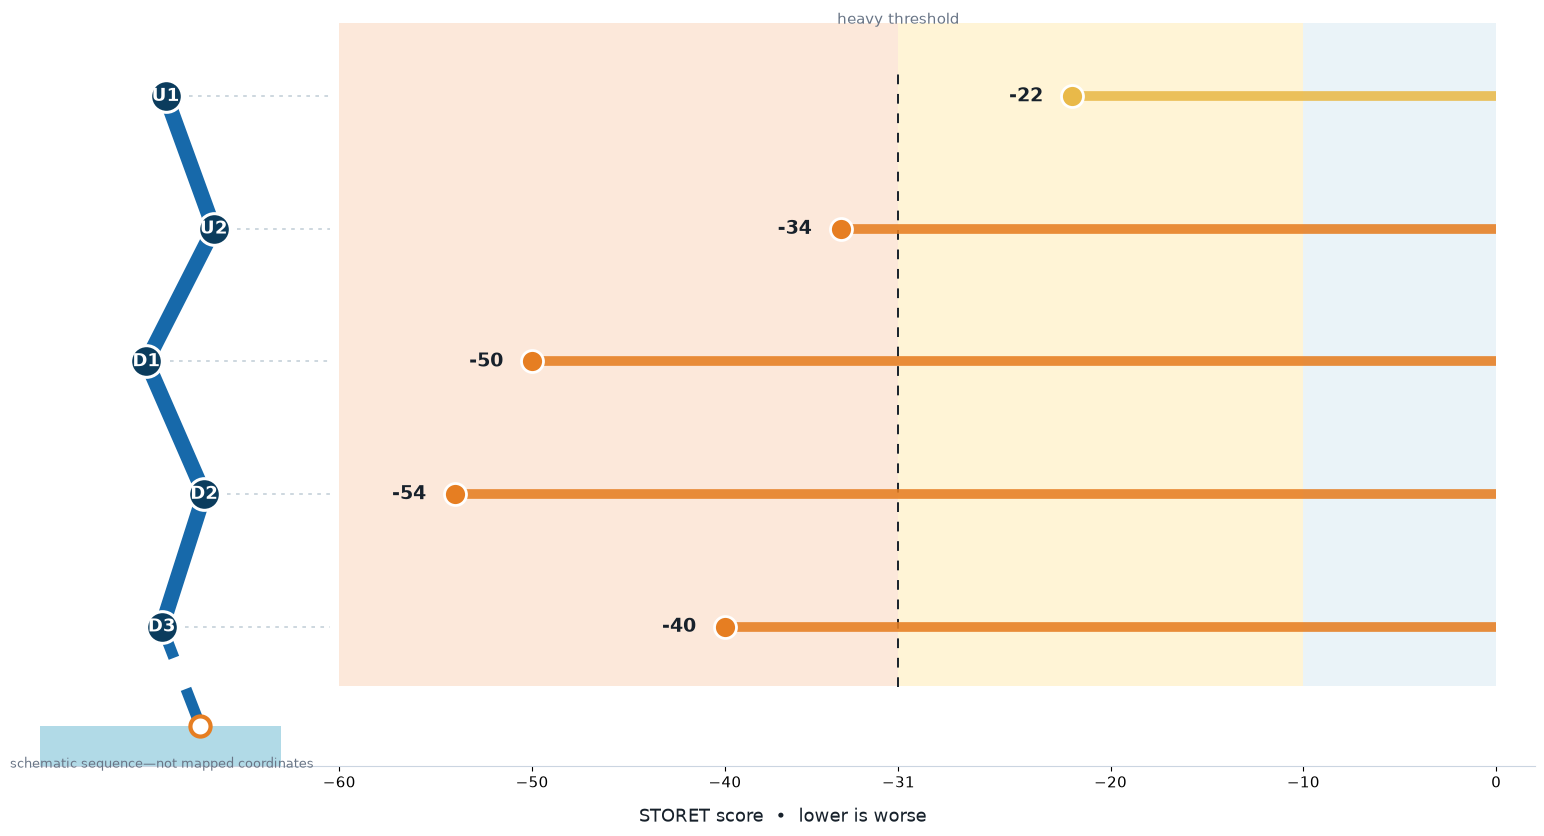

In [ ]:
storet = pd.DataFrame({
    "segment": [
        "Upstream 1", "Upstream 2", "Downstream 1",
        "Downstream 2", "Downstream 3",
    ],
    "short": ["U1", "U2", "D1", "D2", "D3"],
    "score": [-22, -34, -50, -54, -40],
})
storet["status"] = np.where(
    storet["score"] < -31, "Heavily polluted", "Moderately polluted"
)
storet.to_csv(DATA_DIR / "published_storet_scores.csv", index=False)

fig, axis = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor("white")
fig.subplots_adjust(left=0.04, right=0.98, top=0.97, bottom=0.13)

axis.set_xlim(-76, 2)
axis.set_ylim(-1.05, 4.65)

axis.add_patch(plt.Rectangle(
    (-60, -0.45), 29, 5.0, facecolor="#FCE8DA", edgecolor="none", zorder=0
))
axis.add_patch(plt.Rectangle(
    (-31, -0.45), 21, 5.0, facecolor="#FFF4D6", edgecolor="none", zorder=0
))
axis.add_patch(plt.Rectangle(
    (-10, -0.45), 10, 5.0, facecolor="#EAF3F8", edgecolor="none", zorder=0
))
axis.axvline(-31, ymin=0.105, ymax=0.92, color=INK, linewidth=1.4,
             linestyle=(0, (5, 5)), zorder=2)
axis.text(-31, 4.52, "heavy threshold", ha="center", va="bottom",
          fontsize=10.5, color=GREY)

# Schematic sequence only; it does not imply unpublished coordinates.
river_x = np.array([-69.0, -66.5, -70.0, -67.0, -69.2])
river_y = np.array([4, 3, 2, 1, 0], dtype=float)
axis.plot(
    river_x, river_y, color=BLUE, linewidth=11,
    solid_capstyle="round", solid_joinstyle="round", zorder=3,
)
axis.plot(
    [river_x[-1], -67.2], [river_y[-1], -0.75],
    color=BLUE, linewidth=8, linestyle=(0, (3, 3)),
    solid_capstyle="round", zorder=2,
)
axis.add_patch(plt.Rectangle(
    (-75.5, -1.05), 12.5, 0.30,
    facecolor=BLUE_LIGHT, edgecolor="none", alpha=0.9, zorder=1,
))
axis.scatter(
    [-67.2], [-0.75], s=210, facecolor="white",
    edgecolor=ORANGE, linewidth=3, zorder=5,
)

for row_index, row in storet.iterrows():
    y_value = 4 - row_index
    colour = ORANGE if row["status"] == "Heavily polluted" else GOLD
    x_node = river_x[row_index]

    axis.scatter(
        x_node, y_value, s=520, facecolor=BLUE_DARK,
        edgecolor="white", linewidth=2.2, zorder=5,
    )
    axis.text(
        x_node, y_value, row["short"],
        ha="center", va="center", color="white",
        fontsize=13, fontweight="bold", zorder=6,
    )
    axis.hlines(
        y_value, x_node + 1.2, -60.5,
        color="#C9D4DC", linewidth=1.3, linestyle=(0, (2, 3)), zorder=1,
    )
    axis.hlines(
        y_value, row["score"], 0,
        color=colour, linewidth=7, alpha=0.88, zorder=3,
    )
    axis.scatter(
        row["score"], y_value, s=250,
        facecolor=colour, edgecolor="white", linewidth=2.0, zorder=4,
    )
    axis.text(
        row["score"] - 1.5, y_value, str(row["score"]),
        ha="right", va="center", fontsize=14, fontweight="bold",
    )

axis.text(
    -69.2, -0.98, "schematic sequence, not mapped coordinates",
    ha="center", va="top", fontsize=9.5, color=GREY,
)
axis.set_xticks([-60, -50, -40, -31, -20, -10, 0])
axis.set_xlabel("STORET score", labelpad=12)
axis.set_yticks([])
axis.spines[["top", "right", "left"]].set_visible(False)
axis.tick_params(axis="y", length=0)
axis.grid(False)
save_figure(fig, "01_river_segments_and_scores.png")
plt.show()


### Coastal setting


Saved: figures\02_coastal_context_map.png


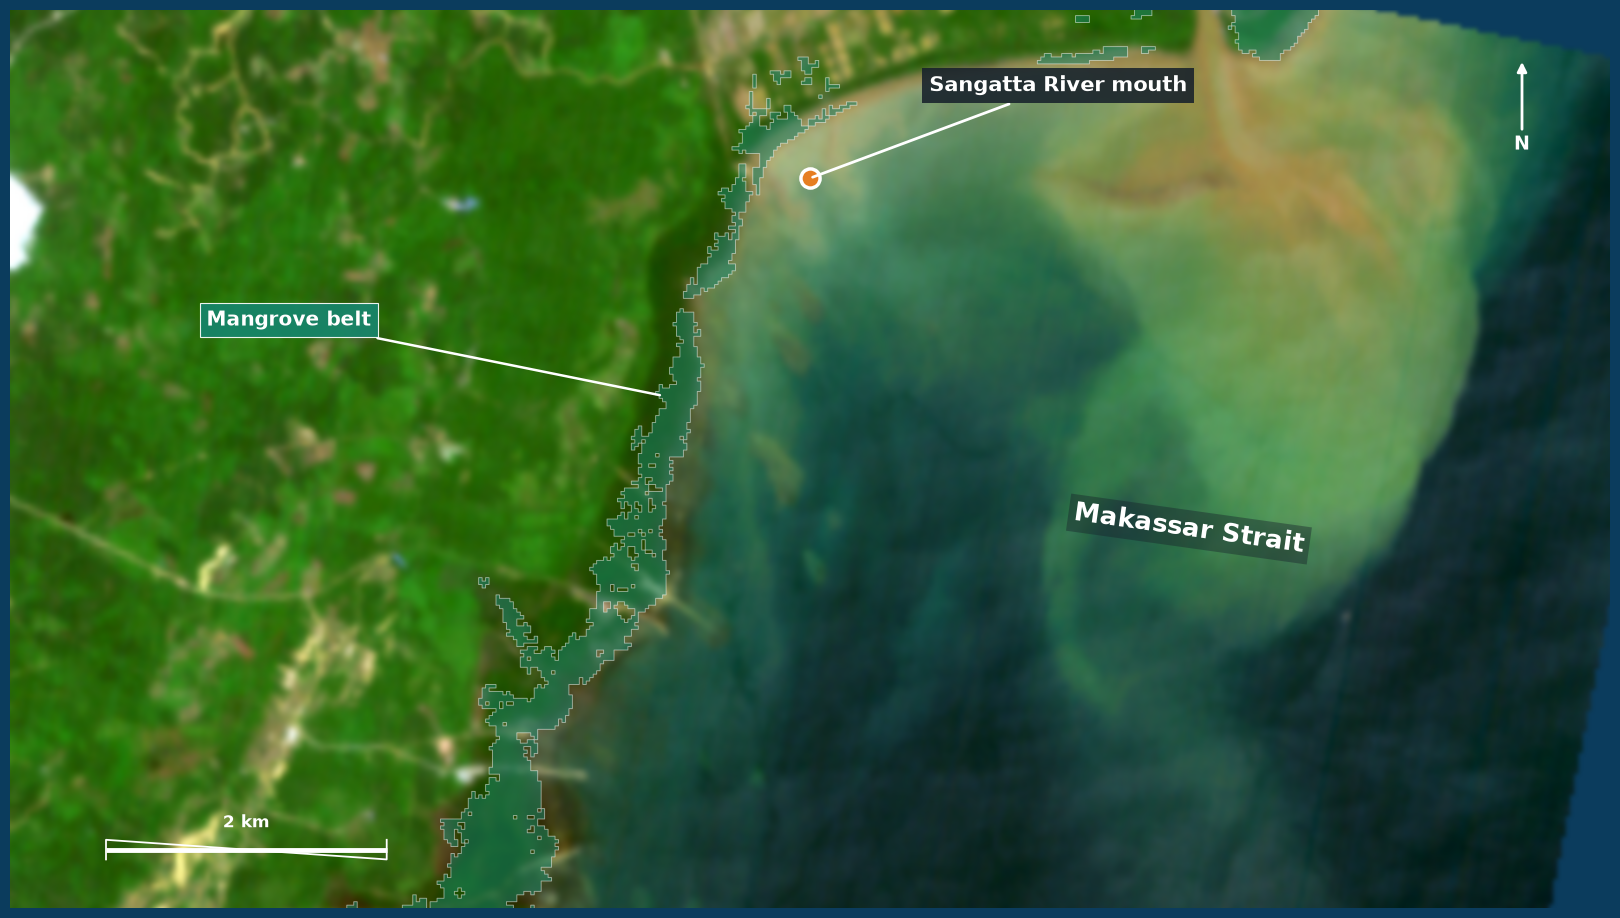

In [7]:
extent = extent_for(target_transform, target_shape)
crop = [
    mouth_centre.x - 5200, mouth_centre.x + 5200,
    mouth_centre.y - 5200, mouth_centre.y + 5200,
]
story_crop = [
    mouth_centre.x - 5700, mouth_centre.x + 5700,
    mouth_centre.y - 5200, mouth_centre.y + 1200,
]
visual_rgba = true_colour_rgba(visual)

fig = plt.figure(figsize=(16, 9), facecolor=BLUE_DARK)
axis = fig.add_axes([0, 0, 1, 1])
axis.set_facecolor(BLUE_DARK)
axis.imshow(
    visual_rgba, extent=extent, interpolation="bicubic", resample=True,
)
mangroves.plot(
    ax=axis, facecolor=GREEN, edgecolor="white",
    linewidth=0.65, alpha=0.52, zorder=5,
)
axis.scatter(
    mouth_centre.x, mouth_centre.y, s=190,
    facecolor=ORANGE, edgecolor="white", linewidth=2.5, zorder=12,
)
axis.annotate(
    "Sangatta River mouth",
    xy=(mouth_centre.x, mouth_centre.y),
    xytext=(mouth_centre.x + 850, mouth_centre.y + 620),
    fontsize=15, fontweight="bold", color="white",
    arrowprops=dict(arrowstyle="-", color="white", linewidth=2.0),
    bbox=dict(facecolor=INK, alpha=0.88, edgecolor="none", pad=5),
    zorder=13,
)
axis.annotate(
    "Mangrove belt",
    xy=(mouth_centre.x - 1050, mouth_centre.y - 1550),
    xytext=(mouth_centre.x - 4300, mouth_centre.y - 1050),
    fontsize=14.5, fontweight="bold", color="white",
    arrowprops=dict(arrowstyle="-", color="white", linewidth=1.8),
    bbox=dict(
        facecolor=GREEN, alpha=0.92, edgecolor="white",
        linewidth=0.8, pad=5,
    ),
    zorder=13,
)
axis.text(
    mouth_centre.x + 2700, mouth_centre.y - 2500,
    "Makassar Strait", color="white", fontsize=19,
    fontweight="bold", rotation=-8, ha="center", va="center",
    bbox=dict(facecolor=INK, alpha=0.42, edgecolor="none", pad=4),
)
axis.set_xlim(story_crop[0], story_crop[1])
axis.set_ylim(story_crop[2], story_crop[3])
axis.set_axis_off()
add_map_furniture(axis)
save_figure(fig, "02_coastal_context_map.png", dpi=450)
plt.show()


### Tanager relative signal


Saved: figures\03_tanager_relative_signal.png


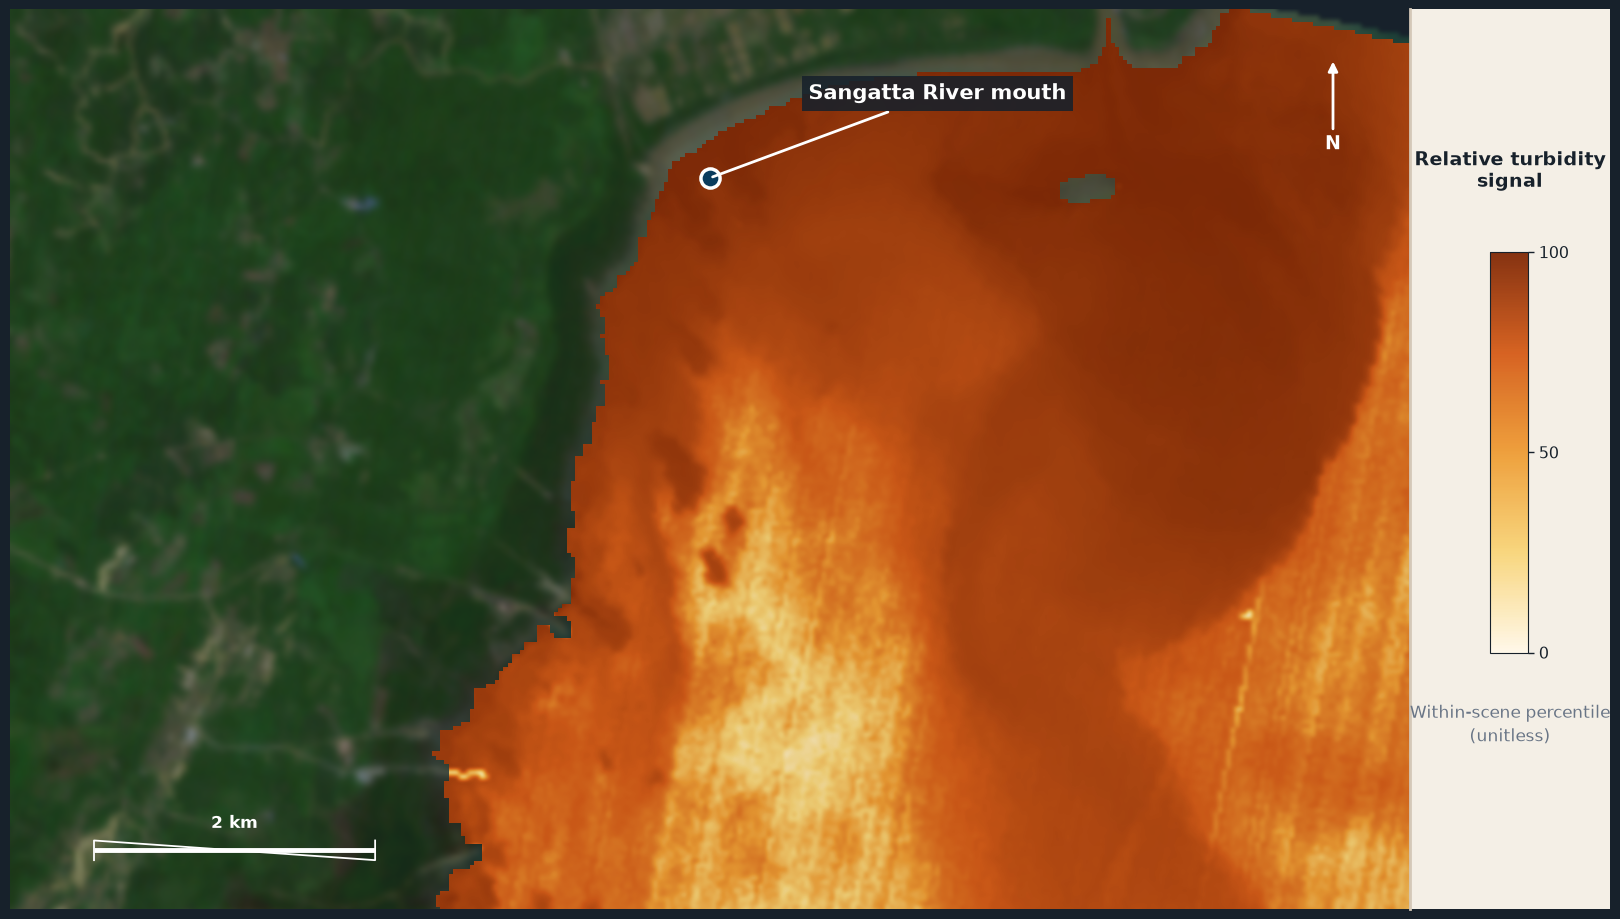

In [8]:
tanager_signal = np.full(target_shape, np.nan, dtype="float32")
tanager_valid = np.isfinite(tanager_turbidity)
tanager_signal[tanager_valid] = (
    100 * rankdata(tanager_turbidity[tanager_valid], method="average")
    / tanager_valid.sum()
)

signal_crop = [
    mouth_centre.x - 4980, mouth_centre.x + 4980,
    mouth_centre.y - 5200, mouth_centre.y + 1200,
]
fig = plt.figure(figsize=(16, 9), facecolor=INK)
map_axis = fig.add_axes([0, 0, 0.875, 1])
legend_axis = fig.add_axes([0.875, 0, 0.125, 1])
map_axis.set_facecolor(INK)
legend_axis.set_facecolor("#F4EFE6")
map_axis.imshow(
    visual_rgba, extent=extent, interpolation="bicubic",
    resample=True, alpha=0.42,
)
signal_image = map_axis.imshow(
    tanager_signal, cmap=SIGNAL_CMAP, vmin=0, vmax=100,
    extent=extent, interpolation="bicubic", resample=True, alpha=0.95,
)
map_axis.scatter(
    mouth_centre.x, mouth_centre.y, s=190,
    facecolor=BLUE_DARK, edgecolor="white", linewidth=2.5, zorder=12,
)
map_axis.annotate(
    "Sangatta River mouth",
    xy=(mouth_centre.x, mouth_centre.y),
    xytext=(mouth_centre.x + 700, mouth_centre.y + 560),
    fontsize=15, fontweight="bold", color="white",
    arrowprops=dict(arrowstyle="-", color="white", linewidth=2.0),
    bbox=dict(facecolor=INK, alpha=0.88, edgecolor="none", pad=5),
    zorder=13,
)
map_axis.set_xlim(signal_crop[0], signal_crop[1])
map_axis.set_ylim(signal_crop[2], signal_crop[3])
map_axis.set_axis_off()
add_map_furniture(map_axis)

legend_axis.set_xlim(0, 1)
legend_axis.set_ylim(0, 1)
legend_axis.set_xticks([])
legend_axis.set_yticks([])
for spine in legend_axis.spines.values():
    spine.set_visible(False)
legend_axis.plot(
    [0.0, 0.0], [0.0, 1.0], color="#D4C8B8", linewidth=2.0,
    transform=legend_axis.transAxes, clip_on=False,
)
legend_axis.text(
    0.50, 0.82, "Relative turbidity\nsignal", ha="center", va="center",
    fontsize=13.5, fontweight="bold", color=INK, linespacing=1.15,
)
colour_axis = fig.add_axes([0.925, 0.285, 0.024, 0.445])
colour_bar = fig.colorbar(signal_image, cax=colour_axis, orientation="vertical")
colour_bar.set_ticks([0, 50, 100])
colour_bar.ax.tick_params(colors=INK, labelsize=11.5, length=4, width=1)
colour_bar.outline.set_edgecolor(INK)
legend_axis.text(
    0.50, 0.205, "Within-scene percentile\n(unitless)",
    ha="center", va="center", fontsize=12,
    color=GREY, linespacing=1.35,
)
save_figure(fig, "03_tanager_relative_signal.png", dpi=450)
plt.show()


### Same-day Sentinel-2 agreement


Saved: figures\04_same_day_independent_check.png


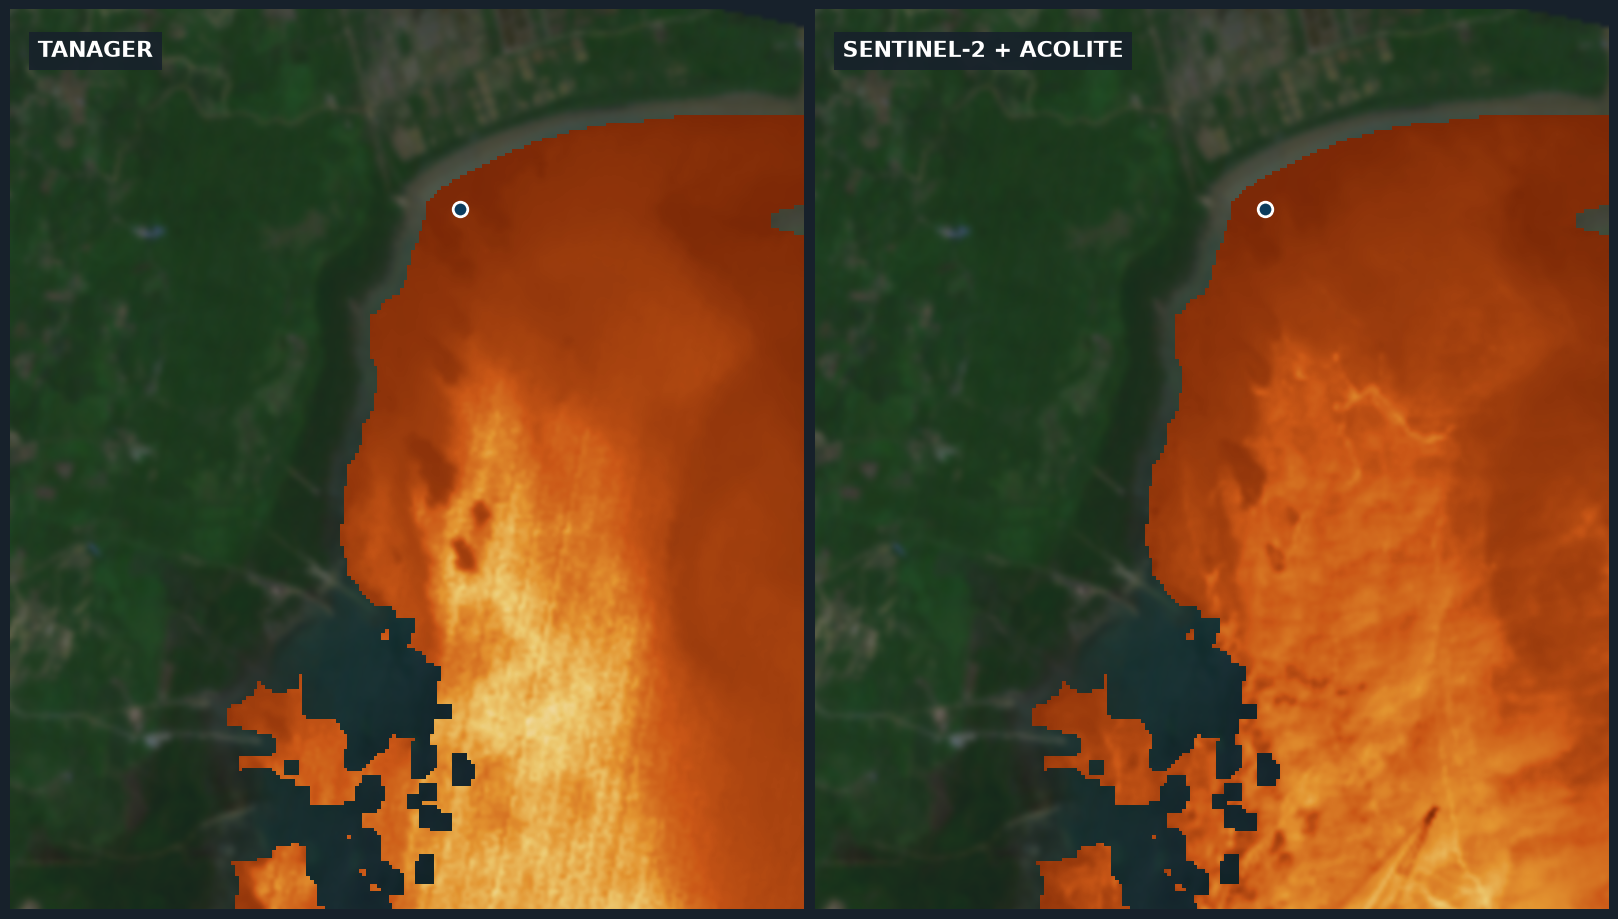

In [9]:
tanager_rank_map = np.full(target_shape, np.nan, dtype="float32")
sentinel_rank_map = np.full(target_shape, np.nan, dtype="float32")
tanager_rank_map[common_water] = (
    100 * rankdata(tanager_values, method="average") / common_water.sum()
)
sentinel_rank_map[common_water] = (
    100 * rankdata(sentinel_values, method="average") / common_water.sum()
)

comparison_crop = [
    mouth_centre.x - 3600, mouth_centre.x + 2750,
    mouth_centre.y - 5600, mouth_centre.y + 1600,
]
fig = plt.figure(figsize=(16, 9), facecolor=INK)
left = fig.add_axes([0.000, 0, 0.497, 1])
right = fig.add_axes([0.503, 0, 0.497, 1])

for axis, image, label in [
    (left, tanager_rank_map, "TANAGER"),
    (right, sentinel_rank_map, "SENTINEL-2 + ACOLITE"),
]:
    axis.set_facecolor(INK)
    axis.imshow(
        visual_rgba, extent=extent, interpolation="bicubic",
        resample=True, alpha=0.36,
    )
    axis.imshow(
        image, cmap=SIGNAL_CMAP, vmin=0, vmax=100,
        extent=extent, interpolation="bicubic", resample=True, alpha=0.96,
    )
    axis.scatter(
        mouth_centre.x, mouth_centre.y, s=110,
        facecolor=BLUE_DARK, edgecolor="white", linewidth=2.0, zorder=10,
    )
    axis.set_xlim(comparison_crop[0], comparison_crop[1])
    axis.set_ylim(comparison_crop[2], comparison_crop[3])
    axis.set_axis_off()
    axis.text(
        0.035, 0.965, label, transform=axis.transAxes,
        va="top", fontsize=15.5, fontweight="bold", color="white",
        bbox=dict(facecolor=INK, alpha=0.90, edgecolor="none", pad=6),
    )

save_figure(fig, "04_same_day_independent_check.png", dpi=450)
plt.show()


### Monitoring-zone ranking


Saved: figures\05a_priority_zone_map.png


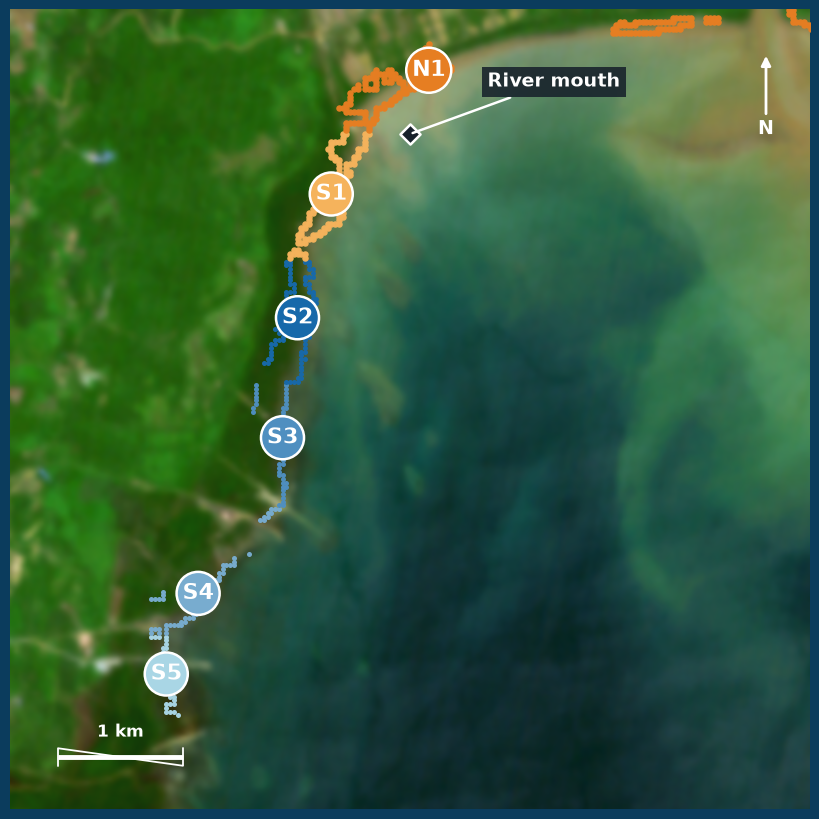

Saved: figures\05b_priority_zone_ranking.png


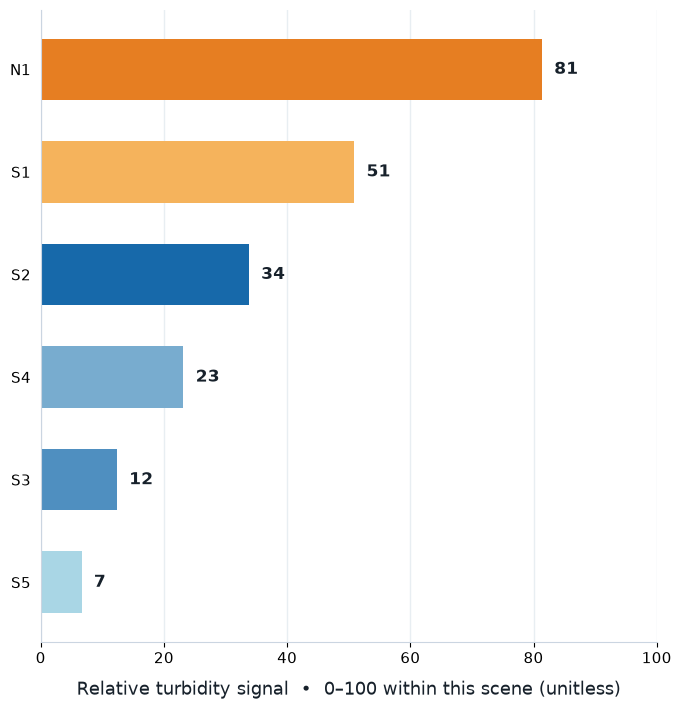

In [10]:
color_by_section = {
    "N1": ORANGE,
    "S1": ORANGE_LIGHT,
    "S2": BLUE,
    "S3": "#4F8FC0",
    "S4": "#78ACCF",
    "S5": BLUE_LIGHT,
}

zone_crop = [
    mouth_centre.x - 3200, mouth_centre.x + 3200,
    mouth_centre.y - 5400, mouth_centre.y + 1000,
]
map_fig = plt.figure(figsize=(8, 8), facecolor=BLUE_DARK)
map_axis = map_fig.add_axes([0, 0, 1, 1])
map_axis.set_facecolor(BLUE_DARK)
map_axis.imshow(
    visual_rgba, extent=extent, interpolation="bicubic",
    resample=True, alpha=0.92,
)
for section, group in edge.groupby("section", observed=True):
    focal = section in ["N1", "S1"]
    map_axis.scatter(
        group["x_utm"], group["y_utm"],
        s=22 if focal else 13,
        color=color_by_section[section],
        linewidths=0, alpha=0.98, zorder=8,
    )
    summary = sections.loc[sections["section"] == section].iloc[0]
    map_axis.text(
        summary["x_label"], summary["y_label"], section,
        ha="center", va="center",
        fontsize=15.5, fontweight="bold", color="white",
        bbox=dict(
            boxstyle="circle,pad=0.28",
            facecolor=color_by_section[section],
            edgecolor="white", linewidth=1.8,
        ),
        zorder=12,
    )
map_axis.scatter(
    mouth_centre.x, mouth_centre.y, marker="D", s=105,
    facecolor=INK, edgecolor="white", linewidth=1.8, zorder=13,
)
map_axis.annotate(
    "River mouth",
    xy=(mouth_centre.x, mouth_centre.y),
    xytext=(mouth_centre.x + 620, mouth_centre.y + 380),
    fontsize=13.5, fontweight="bold", color="white",
    arrowprops=dict(arrowstyle="-", color="white", linewidth=1.8),
    bbox=dict(facecolor=INK, alpha=0.88, edgecolor="none", pad=4),
    zorder=13,
)
map_axis.set_xlim(zone_crop[0], zone_crop[1])
map_axis.set_ylim(zone_crop[2], zone_crop[3])
map_axis.set_axis_off()
add_map_furniture(map_axis, length_m=1000)
save_figure(map_fig, "05a_priority_zone_map.png", dpi=450)
plt.show()

rank_fig, rank_axis = plt.subplots(figsize=(8, 8))
rank_fig.patch.set_facecolor("white")
rank_fig.subplots_adjust(left=0.17, right=0.94, top=0.94, bottom=0.15)
ranked = sections.sort_values("relative_signal_score", ascending=True)
bars = rank_axis.barh(
    ranked["section"], ranked["relative_signal_score"],
    color=[color_by_section[value] for value in ranked["section"]],
    height=0.60,
)
clean_axis(rank_axis)
rank_axis.set_xlim(0, 100)
rank_axis.set_xlabel(
    "Relative turbidity signal  •  0–100 within this scene (unitless)", labelpad=10,
)
rank_axis.set_ylabel("")
rank_axis.tick_params(axis="y", length=0, pad=7)
for bar, value in zip(bars, ranked["relative_signal_score"]):
    rank_axis.text(
        min(value + 2.0, 94),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}",
        va="center", fontsize=12.5, fontweight="bold",
    )
save_figure(rank_fig, "05b_priority_zone_ranking.png")
plt.show()


### Monitoring concept


Saved: figures\06_more_tanager_monitoring_concept.png


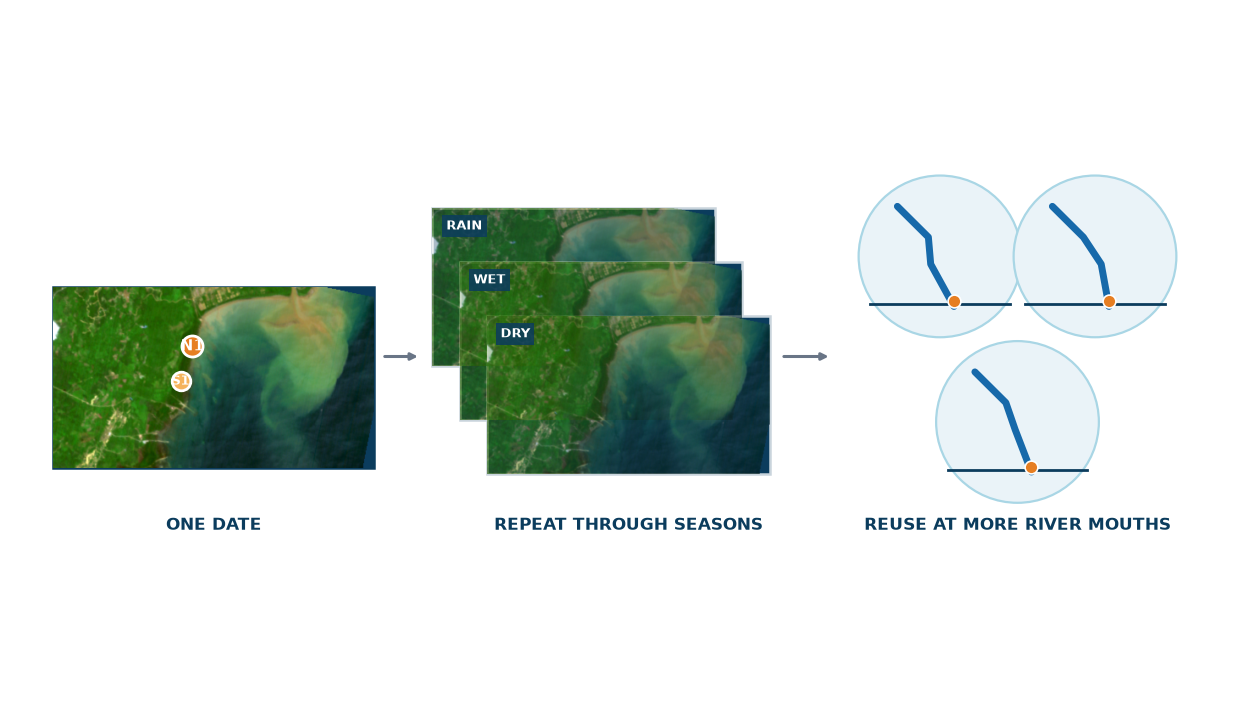

In [11]:
# Only the first card depicts an observed date; later cards introduce no measurements.
fig, axis = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor("white")
axis.set_xlim(0, 16)
axis.set_ylim(0, 9)
axis.set_axis_off()

top_row, left_col = rasterio.transform.rowcol(
    target_transform, story_crop[0], story_crop[3]
)
bottom_row, right_col = rasterio.transform.rowcol(
    target_transform, story_crop[1], story_crop[2]
)
top_row = max(0, min(target_shape[0], top_row))
bottom_row = max(0, min(target_shape[0], bottom_row))
left_col = max(0, min(target_shape[1], left_col))
right_col = max(0, min(target_shape[1], right_col))
story_thumbnail = visual_rgba[
    min(top_row, bottom_row):max(top_row, bottom_row),
    min(left_col, right_col):max(left_col, right_col),
]

def map_card(x0, y0, width, height, alpha=1.0, edge=BLUE_DARK):
    axis.add_patch(plt.Rectangle(
        (x0, y0), width, height,
        facecolor=BLUE_DARK, edgecolor=edge, linewidth=1.8,
    ))
    axis.imshow(
        story_thumbnail,
        extent=[x0, x0 + width, y0, y0 + height],
        interpolation="bilinear", alpha=alpha, aspect="auto", zorder=2,
    )

map_card(0.55, 3.05, 4.15, 2.35)
axis.scatter(2.35, 4.63, s=230, facecolor=ORANGE,
             edgecolor="white", linewidth=2, zorder=6)
axis.scatter(2.20, 4.18, s=180, facecolor=ORANGE_LIGHT,
             edgecolor="white", linewidth=2, zorder=6)
axis.text(2.35, 4.63, "N1", ha="center", va="center",
          fontsize=10.5, fontweight="bold", color="white", zorder=7)
axis.text(2.20, 4.18, "S1", ha="center", va="center",
          fontsize=9.5, fontweight="bold", color="white", zorder=7)
axis.text(2.63, 2.25, "ONE DATE", ha="center", fontsize=12,
          fontweight="bold", color=BLUE_DARK)

condition_cards = [
    (5.45, 4.38, "RAIN"),
    (5.80, 3.68, "WET"),
    (6.15, 2.98, "DRY"),
]
for x0, y0, label in condition_cards:
    map_card(x0, y0, 3.65, 2.05, alpha=0.66, edge="#C9D4DC")
    axis.text(
        x0 + 0.18, y0 + 1.77, label,
        fontsize=9.5, fontweight="bold", color="white",
        bbox=dict(facecolor=BLUE_DARK, alpha=0.86,
                  edgecolor="none", pad=3),
        zorder=5,
    )
axis.text(7.98, 2.25, "REPEAT THROUGH SEASONS", ha="center", fontsize=12,
          fontweight="bold", color=BLUE_DARK)

# These icons are schematic and do not claim results for unanalysed sites.
icon_centres = [(12.0, 5.8), (14.0, 5.8), (13.0, 3.65)]
for index, (cx, cy) in enumerate(icon_centres):
    axis.add_patch(plt.Circle(
        (cx, cy), 1.05, facecolor="#EAF3F8",
        edgecolor=BLUE_LIGHT, linewidth=1.6,
    ))
    offset = [-0.12, 0.08, -0.03][index]
    axis.plot(
        [cx - 0.55, cx - 0.15, cx + offset, cx + 0.18],
        [cy + 0.65, cy + 0.25, cy - 0.10, cy - 0.65],
        color=BLUE, linewidth=5, solid_capstyle="round",
    )
    axis.plot(
        [cx - 0.90, cx + 0.90],
        [cy - 0.62, cy - 0.62],
        color=BLUE_DARK, linewidth=2.0,
    )
    axis.scatter(
        cx + 0.18, cy - 0.58, s=85,
        facecolor=ORANGE, edgecolor="white", linewidth=1.2, zorder=5,
    )
axis.text(13.0, 2.25, "REUSE AT MORE RIVER MOUTHS", ha="center", fontsize=12,
          fontweight="bold", color=BLUE_DARK)

for start_x, end_x in [(4.80, 5.30), (9.95, 10.60)]:
    axis.annotate(
        "", xy=(end_x, 4.5), xytext=(start_x, 4.5),
        arrowprops=dict(arrowstyle="-|>", color=GREY, linewidth=2.2),
    )
save_figure(fig, "06_more_tanager_monitoring_concept.png")
plt.show()


## What this supports

The published STORET measurements establish the river concern. The
Tanager relative signal and same-day Sentinel-2 agreement identify
where to begin coastal follow-up. The monitoring-zone ranking puts N1
and S1 first for repeat observation. Repeated Tanager scenes can show
whether the same zones remain elevated across rainfall and seasons.

A separate broader Notebook 5 water-product comparison between physics-based FNU and AI TSS reports Spearman 0.77 across its full-water mask. Notebook 6's 0.797 uses a stricter common valid-pixel same-day validation mask, so it is not the same subset.


In [12]:
top_two = sections.nsmallest(2, "monitoring_rank")
print("DOCUMENTED GAP")
print("- Five river sampling segments do not provide a continuous coastal map.")
print("\nWHAT THIS WORKFLOW ADDS")
print(f"- {int(common_water.sum()):,} same-day matched water pixels.")
print(f"- Strong spatial agreement: rho = {rank_agreement:.3f}.")
print("- Six fixed 1 km coastal monitoring zones.")
print("- First repeat-monitoring zones:",
      ", ".join(top_two["section"].tolist()))
print("\nWHO CAN USE IT")
print("- East Kutai environmental authorities, community monitors, and coastal managers.")
print("\nWHAT MORE TANAGER DATA ADDS")
print("- Tests whether the same sections remain elevated across rainfall and seasons.")

DOCUMENTED GAP
- Five river sampling segments do not provide a continuous coastal map.

WHAT THIS WORKFLOW ADDS
- 170,007 same-day matched water pixels.
- Strong spatial agreement: rho = 0.854.
- Six fixed 1 km coastal monitoring zones.
- First repeat-monitoring zones: N1, S1

WHO CAN USE IT
- East Kutai environmental authorities, community monitors, and coastal managers.

WHAT MORE TANAGER DATA ADDS
- Tests whether the same sections remain elevated across rainfall and seasons.


## References

- Sandra et al. (2025), Sangatta River water-quality assessment:
  https://doi.org/10.30872/1m2ktd59
- Dogliotti et al. (2015), satellite turbidity algorithm:
  https://doi.org/10.1016/j.rse.2014.09.020
- Vanhellemont (2019), ACOLITE atmospheric correction:
  https://doi.org/10.1016/j.rse.2019.03.010
- Amran & Daming (2023), continuous coastal turbidity mapping in
  Indonesia: https://doi.org/10.3846/gac.2023.18132
- Al Hakim et al. (2023), seasonal/tidal turbidity-front movement in an
  Indonesian estuary: https://doi.org/10.29244/jitkt.v14i3.40172